<a href="https://colab.research.google.com/github/renzoardiles-pixel/Colab-UNI/blob/main/SQL/SESI%C3%93N_2_PROCEDIMIENTOS_ALMACENADOS_AVANZADOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

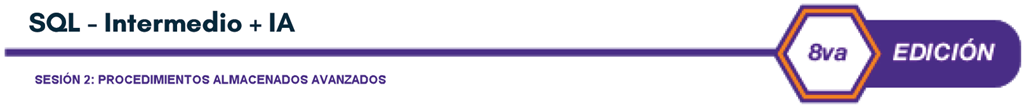

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Variables Locales</font>**

</td>
</tr>
</table>

 Las variables son objetos que se utilizan para almacenar datos temporales en el contexto de una sesión o bloque de código.

 Estas variables pueden contener diferentes tipos de datos, como enteros, cadenas de texto, fechas, etc

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Tipos de Variables</font>**

</td>
</tr>
</table>

>* **Variables locales**: Se definen con el símbolo @ y se utilizan solamente dentro del bloque donde fueron declaradas.
    * **Ejemplo**: DECLARE @miVariable INT;
>* **Variables globales**: Se definen con el símbolo @@ y son accesibles desde cualquier sesión.
    * **Ejemplo**: SELECT @@VERSION;



```
-- Cantidad de Beneficiarios de 0 años al 30/09/2004
USE PVL
GO
SELECT
	fec_nac_ben_da,
	DATEDIFF(YEAR, fec_nac_ben_da, '2004-09-30') AS EdadSQL,
	DATEDIFF(DAY, fec_nac_ben_da, '2004-09-30')/365.256363004 AS EdadPVL,
	CONVERT(INT, DATEDIFF(DAY, fec_nac_ben_da, '2004-09-30')/365.256363004) AS EdadPVL
FROM Beneficiario
WHERE
		DATEDIFF(YEAR, fec_nac_ben_da, '2004-09-30')
	<>
		CONVERT(INT, DATEDIFF(DAY, fec_nac_ben_da, '2004-09-30')/365.256363004)
```





```
-- Cantidad de Beneficiarios de 0 años al 30/09/2004
USE PVL
GO
SELECT
	COUNT(*) AS [Cantidad de Beneficiarios de 0 Años]
FROM Beneficiario
WHERE
	CONVERT(INT, DATEDIFF(DAY, fec_nac_ben_da, '2004-09-30')/365.256363004) = 0
```



<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Primera forma de asignar un valor a una variable</font>**

</td>
</tr>
</table>



```
-- Cantidad de Beneficiarios de 0 años al 30/09/2004
USE PVL
GO
DECLARE @N_0 INT;

SELECT @N_0 = COUNT(*)
FROM Beneficiario
WHERE CONVERT(INT, DATEDIFF(DAY, fec_nac_ben_da, '2004-09-30')/365.256363004) = 0;

SELECT @N_0 AS [Cantidad de Beneficiarios de 0 Años];
```



<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Segunda forma de asignar un valor a una variable</font>**

</td>
</tr>
</table>



```
-- Cantidad de Beneficiarios de 0 años al 30/09/2004
USE PVL
GO
DECLARE @N_0 INT;

SET @N_0 =
(
	SELECT COUNT(*)
	FROM Beneficiario
	WHERE CONVERT(INT, DATEDIFF(DAY, fec_nac_ben_da, '2004-09-30')/365.256363004) = 0
)

SELECT @N_0 AS [Cantidad de Beneficiarios de 0 Años];
```



<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Tercera forma de asignar un valor a una variable</font>**

</td>
</tr>
</table>



```
-- Cantidad de Beneficiarios de 0 años al 30/09/2004
USE PVL
GO
DECLARE @N_0 INT =
(
	SELECT COUNT(*)
	FROM Beneficiario
	WHERE CONVERT(INT, DATEDIFF(DAY, fec_nac_ben_da, '2004-09-30')/365.256363004) = 0
)

SELECT @N_0 AS [Cantidad de Beneficiarios de 0 Años];
```



<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Uso de Variables</font>**

</td>
</tr>
</table>

Las variables se utilizan a menudo en procedimientos almacenados, funciones y scripts SQL para almacenar resultados intermedios o para llevar a cabo cálculos.

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Ventajas de Usar Variables</font>**

</td>
</tr>
</table>

>* **Modularidad**: Permiten crear scripts más organizados y legibles.
>* **Almacenamiento temporal**: Se pueden usar para almacenar resultados intermedios sin necesidad de crear tablas temporales.

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Consideraciones</font>**

</td>
</tr>
</table>

>* **Alcance**: Las variables tienen un alcance limitado al bloque o procedimiento donde se declaran.
>* **Tipado**: Es importante declarar el tipo de dato correctamente, ya que una variable se comportará de acuerdo al tipo de dato SQL que se le asigne.

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Parámetros de Salida (OUTPUT)</font>**

</td>
</tr>
</table>



```
-- Northwind: Crear un procedimiento almacenado llamado usp_producto_consulta
-- que acepte un parámetro de entrada llamado @ProductID de tipo int y
-- devuelva los detalles del producto correspondiente de la tabla Products.
USE Northwind;
GO
CREATE OR ALTER PROCEDURE dbo.usp_producto_consulta
	@ProductID			int,
	@ProductName		nvarchar(40)	OUTPUT,
	@UnitPrice			money			OUTPUT,
	@UnitsInStock		smallint		OUTPUT,
	@Discontinued		bit				OUTPUT
AS
BEGIN
	SET NOCOUNT ON;
	SELECT
		@ProductName = ProductName,
		@UnitPrice = UnitPrice,
		@UnitsInStock = UnitsInStock,
		@Discontinued = Discontinued
	FROM
		dbo.Products
	WHERE
		ProductID = @ProductID;
	RETURN 0;
END;

GO

DECLARE @RC int
DECLARE @ProductID int = 10
DECLARE @ProductName nvarchar(40)
DECLARE @UnitPrice money
DECLARE @UnitsInStock smallint
DECLARE @Discontinued bit

-- TODO: Establezca los valores de los parámetros aquí.

EXECUTE @RC = [dbo].[usp_producto_consulta]
   @ProductID
  ,@ProductName OUTPUT  
  ,@UnitPrice OUTPUT
  ,@UnitsInStock OUTPUT
  ,@Discontinued OUTPUT

SELECT @ProductName AS N'Producto',
	   @UnitPrice AS N'Precio',
	   @UnitsInStock AS N'Stock',
	   @Discontinued AS N'Estado'

SELECT @RC AS N'Error'
GO

```





```
-- Convertir un numero entre 1 y 3999 a numeros romanos

CREATE OR ALTER PROCEDURE usp_convertir_numero_a_romano
(
	@n INT,
	@rom VARCHAR(500) OUTPUT
)
AS
BEGIN
	DECLARE @valores TABLE (valor INT, simbolo VARCHAR(5))
	INSERT INTO @valores (valor, simbolo)
	VALUES
		(1000, 'M'),
		(900, 'CM'),
		(500, 'D'),
		(400, 'CD'),
		(100, 'C'),
		(90, 'XC'),
		(50, 'L'),
		(40, 'XL'),
		(10, 'X'),
		(9, 'IX'),
		(5, 'V'),
		(4, 'IV'),
		(1, 'I')
	SET @rom = ''
	DECLARE @i INT = 1
	DECLARE @valor INT
	DECLARE @simbolo VARCHAR(5)
	WHILE @n > 0
	BEGIN
		SELECT TOP 1 @valor = valor, @simbolo = simbolo
		FROM @valores
		WHERE valor <= @n
		ORDER BY valor DESC
		SET @rom = @rom + @simbolo
		SET @n = @n - @valor
	END
END
GO
USE [Northwind]
GO

DECLARE @RC int
DECLARE @n int = 999
DECLARE @rom varchar(500)

-- TODO: Establezca los valores de los parámetros aquí.

EXECUTE @RC = [dbo].[usp_convertir_numero_a_romano]
   @n
  ,@rom OUTPUT

SELECT @rom AS N'Número Romano'
GO
```





```
SELECT 5 / 2 AS Result;
SELECT 5 / 2.0 AS Result;
SELECT CAST(5 AS FLOAT) / 2 AS Result;
```



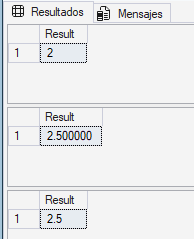



```
SELECT 5 % 2 AS Residuo;
```



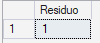



```
-- Convertir un numero entre 1 y 3999 a numeros romanos
-- Sin usar INSERT INTO o tablas auxiliares

CREATE OR ALTER PROCEDURE usp_convertir_numero_a_romano
(
	@n INT,
	@rom VARCHAR(500) OUTPUT
)
AS
BEGIN
	SET NOCOUNT ON;

	IF @n < 1 OR @n > 3999
	BEGIN
		SET @rom = 'Número fuera de rango';
		RETURN -1;
	END
	ELSE
	BEGIN
		DECLARE @M INT = @n / 1000;
		SET @n %= 1000;

		DECLARE @C INT = @n / 100;
		SET @n %= 100;

		DECLARE @D INT = @n / 10;
		DECLARE @U INT = @n % 10;

	END

	SELECT @M AS Millares, @C AS Centenas, @D AS Decenas, @U AS Unidades;

	RETURN 0
END
GO
DECLARE @RC INT;
DECLARE @n INT = 1234;
DECLARE @rom VARCHAR(500);
EXECUTE @RC = dbo.usp_convertir_numero_a_romano
	@n = @n,
	@rom = @rom OUTPUT;
SELECT @rom AS N'Número Romano';
```



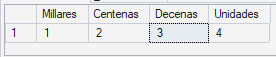



```
-- Convertir un numero entre 1 y 3999 a numeros romanos
-- Sin usar INSERT INTO o tablas auxiliares

CREATE OR ALTER PROCEDURE usp_convertir_numero_a_romano
(
	@n INT,
	@rom VARCHAR(500) OUTPUT
)
AS
BEGIN
	SET NOCOUNT ON;

	IF @n < 1 OR @n > 3999
	BEGIN
		SET @rom = 'Número fuera de rango';
		RETURN -1;
	END
	ELSE
	BEGIN
		DECLARE @M INT = @n / 1000;
		SET @n %= 1000;

		DECLARE @C INT = @n / 100;
		SET @n %= 100;

		DECLARE @D INT = @n / 10;
		DECLARE @U INT = @n % 10;

		SET @rom = REPLICATE('M', @M);
		SET @rom +=
			CASE
				WHEN @C = 9 THEN 'CM'
				WHEN @C >= 5 THEN 'D' + REPLICATE('C', @C - 5)
				WHEN @C = 4 THEN 'CD'
				ELSE REPLICATE('C', @C)
			END;
		SET @rom +=
			CASE
			WHEN @D = 9 THEN 'XC'
				WHEN @D >= 5 THEN 'L' + REPLICATE('X', @D - 5)
				WHEN @D = 4 THEN 'XL'
				ELSE REPLICATE('X', @D)
			END;
		SET @rom +=
			CASE
			WHEN @U = 9 THEN 'IX'
				WHEN @U >= 5 THEN 'V' + REPLICATE('I', @U - 5)
				WHEN @U = 4 THEN 'IV'
				ELSE REPLICATE('I', @U)
			END;
	END

	RETURN 0
END
GO
DECLARE @RC INT;
DECLARE @n INT = 3999;
DECLARE @rom VARCHAR(500);
EXECUTE @RC = dbo.usp_convertir_numero_a_romano
	@n = @n,
	@rom = @rom OUTPUT;
SELECT @rom AS N'Número Romano';
GO
```





```
-- Convertir un numero entre 0 y 9999 a palabras en español
-- Ejemplo: 12 -> DOCE
-- Sin usar INSERT INTO o tablas auxiliares

CREATE OR ALTER PROCEDURE usp_convertir_numero_a_palabras
(
	@n INT,
	@pal VARCHAR(500) OUTPUT
)
AS
BEGIN
	SET NOCOUNT ON;

	IF @n < 0 OR @n > 9999
	BEGIN
		SET @pal = 'Número fuera de rango';
		RETURN -1;
	END
	ELSE
	BEGIN
		IF @n = 0
		BEGIN
			SET @pal = 'CERO';
			RETURN 0;
		END
		ELSE
		BEGIN
			DECLARE @M INT = @n / 1000;
			SET @n %= 1000;

			DECLARE @C INT = @n / 100;
			SET @n %= 100;

			DECLARE @D INT = @n / 10;
			DECLARE @U INT = @n % 10;

			-- Miles
			SET @pal = CASE @M
				WHEN 1 THEN 'MIL '
				WHEN 2 THEN 'DOS MIL '
				WHEN 3 THEN 'TRES MIL '
				WHEN 4 THEN 'CUATRO MIL '
				WHEN 5 THEN 'CINCO MIL '
				WHEN 6 THEN 'SEIS MIL '
				WHEN 7 THEN 'SIETE MIL '
				WHEN 8 THEN 'OCHO MIL '
				WHEN 9 THEN 'NUEVE MIL '
				ELSE ''
			END;
			-- Centenas
			SET @pal += CASE @C
				WHEN 1 THEN CASE WHEN @D = 0 AND @U = 0 THEN 'CIEN' ELSE 'CIENTO ' END
				WHEN 2 THEN 'DOSCIENTOS '
				WHEN 3 THEN 'TRESCIENTOS '
				WHEN 4 THEN 'CUATROCIENTOS '
				WHEN 5 THEN 'QUINIENTOS '
				WHEN 6 THEN 'SEISCIENTOS '
				WHEN 7 THEN 'SETECIENTOS '
				WHEN 8 THEN 'OCHOCIENTOS '
				WHEN 9 THEN 'NOVECIENTOS '
				ELSE ''
			END;
			-- Decenas y Unidades
			IF @D = 1
			BEGIN
				SET @pal += CASE @U
					WHEN 0 THEN 'DIEZ'
					WHEN 1 THEN 'ONCE'
					WHEN 2 THEN 'DOCE'
					WHEN 3 THEN 'TRECE'
					WHEN 4 THEN 'CATORCE'
					WHEN 5 THEN 'QUINCE'
					WHEN 6 THEN 'DIECISÉIS'
					WHEN 7 THEN 'DIECISIETE'
					WHEN 8 THEN 'DIECIOCHO'
					WHEN 9 THEN 'DIECINUEVE'
				END;
			END
			ELSE
			BEGIN
				SET @pal += CASE @D
					WHEN 2 THEN CASE WHEN @U = 0 THEN 'VEINTE' ELSE 'VEINTI' END
					WHEN 3 THEN 'TREINTA' + CASE WHEN @U > 0 THEN ' Y ' ELSE '' END
					WHEN 4 THEN 'CUARENTA' + CASE WHEN @U > 0 THEN ' Y ' ELSE '' END
					WHEN 5 THEN 'CINCUENTA' + CASE WHEN @U > 0 THEN ' Y ' ELSE '' END
					WHEN 6 THEN 'SESENTA' + CASE WHEN @U > 0 THEN ' Y ' ELSE '' END
					WHEN 7 THEN 'SETENTA' + CASE WHEN @U > 0 THEN ' Y ' ELSE '' END
					WHEN 8 THEN 'OCHENTA' + CASE WHEN @U > 0 THEN ' Y ' ELSE '' END
					WHEN 9 THEN 'NOVENTA' + CASE WHEN @U > 0 THEN ' Y ' ELSE '' END
					ELSE ''
				END;
				SET @pal += CASE @U
					WHEN 1 THEN 'UNO'
					WHEN 2 THEN 'DOS'
					WHEN 3 THEN 'TRES'
					WHEN 4 THEN 'CUATRO'
					WHEN 5 THEN 'CINCO'
					WHEN 6 THEN 'SEIS'
					WHEN 7 THEN 'SIETE'
					WHEN 8 THEN 'OCHO'
					WHEN 9 THEN 'NUEVE'
					ELSE ''
				END;
			END
		END
	END
	RETURN 0
END
GO
-- Ejemplo de uso
DECLARE @RC INT
DECLARE @n INT = 1234
DECLARE @pal VARCHAR(500)
EXECUTE @RC = usp_convertir_numero_a_palabras @n, @pal OUTPUT
SELECT @pal AS N'Número en palabras'
--SELECT @RC AS N'Error'
GO

```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Diferencia entre RETURN (códigos de estado) y parámetros OUTPUT</font>**

</td>
</tr>
</table>

En SQL Server, tanto RETURN como los parámetros OUTPUT se utilizan para pasar información entre procedimientos almacenados, pero tienen diferencias importantes en su funcionamiento y uso.

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">RETURN</font>**

</td>
</tr>
</table>

>* **Uso Principal**: Se utiliza para devolver un código de estado entero desde un procedimiento almacenado. Esto se utiliza comúnmente para indicar el éxito o fracaso de la ejecución de un procedimiento.
>* **Rango de Valores**: Solo puede devolver un valor entero (generalmente, 0 para éxito y otros números para diferentes tipos de error o estados).
>* **Declaración**: Se utiliza al final de un procedimiento con la sintaxis RETURN <value>.
>* **Costo de Uso**: Se utiliza en situaciones donde solo necesitas devolver un código de estado simple.
>* **Accesibilidad**: El valor devuelto por RETURN se puede recuperar al ejecutar el procedimiento, pero no se puede usar para devolver múltiples valores.

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Parámetros OUTPUT</font>**

</td>
</tr>
</table>

>* **Uso Principal**: Se utilizan para devolver múltiples valores desde un procedimiento almacenado. Permiten pasar valores de vuelta a la llamada que invoca el procedimiento.
>* **Rango de Valores**: Pueden ser de diferentes tipos de datos (enteros, cadenas, etc.), lo que permite más flexibilidad.
>* **Declaración**: Se define al declarar el parámetro en el procedimiento, utilizando la palabra clave OUTPUT.
>* **Costo de Uso**: Se suelen usar cuando se necesitan retornar múltiples resultados o datos complejos desde el procedimiento.
>* **Accesibilidad**: Se deben especificar como OUTPUT al llamar al procedimiento, y sus valores se pueden manipular después de la llamada.

| Característica            | `RETURN`                       | Parámetros `OUTPUT`           |
|--------------------------|-------------------------------|-------------------------------|
| Tipo de Dato             | Solo entero                   | Varios tipos de datos         |
| Número de Valores        | Solo uno                      | Múltiples                     |
| Uso Principal            | Código de estado              | Resultados de datos           |
| Sintaxis de Llamada      | `RETURN <value>`              | `EXEC procedimiento @param OUTPUT` |
| Alcance de Uso           | Limitado a indicar estados    | Para pasar datos complejos    |


<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Conjuntos de Resultados (Result Sets)</font>**

</td>
</tr>
</table>

En SQL Server, un conjunto de resultados (o result set) se refiere a la colección de filas retornadas como resultado de una consulta SQL o de la ejecución de un procedimiento almacenado.



```
USE Northwind;
GO
CREATE OR ALTER PROCEDURE usp_cliente_consulta
	@CustomerID nchar(5)
AS
BEGIN
	SET NOCOUNT ON;
	SELECT
		CustomerID,
		CompanyName,
		ContactName,
		ContactTitle,
		Address,
		City,
		Region,
		PostalCode,
		Country,
		Phone,
		Fax
	FROM
		dbo.Customers
	WHERE
		CustomerID = @CustomerID;

	SELECT
		o.OrderID,
		o.OrderDate,
		o.RequiredDate,
		o.ShippedDate,
		s.CompanyName AS ShipperName,
		o.Freight,
		o.ShipName,
		o.ShipCity,
		o.ShipCountry
	FROM
		dbo.Orders o
	INNER JOIN Shippers s
	ON o.ShipVia = s.ShipperID
	WHERE
		CustomerID = @CustomerID
END
GO
-- Example execution:
EXEC usp_cliente_consulta @CustomerID = 'ALFKI';
GO
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Función IIF y CHOOSE</font>**

</td>
</tr>
</table>

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Función IIF</font>**

</td>
</tr>
</table>



```
USE pvl
GO
SELECT
	cod_ben_in AS Codigo,
	nom_ben_vc AS Nombre,
	pat_ben_vc AS Paterno,
	mat_ben_vc AS Materno,
	dni_ben_ch AS DNI,
	IIF(cod_sex_bi = 0, 'FEMENINO', 'MASCULINO') AS Sexo
FROM Beneficiario;
GO
```



<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Función CHOOSE</font>**

</td>
</tr>
</table>

La función CHOOSE permite seleccionar un valor de una lista de valores en función de un índice proporcionado.

Es útil cuando se necesita retornar uno de varios valores sin usar múltiples declaraciones IF o CASE.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Sintaxis</font>**

</td>
</tr>
</table>



```
CHOOSE(Índice, Valor1, Valor2, Valor3, ..., ValorN)
```





```
USE pvl
GO
SELECT
	cod_ben_in AS Codigo,
	nom_ben_vc AS Nombre,
	pat_ben_vc AS Paterno,
	mat_ben_vc AS Materno,
	dni_ben_ch AS DNI,
	CHOOSE(cod_sex_bi + 1, 'FEMENINO', 'MASCULINO') AS Sexo
FROM Beneficiario;
GO
```





```
SELECT
	CHOOSE
	(
		DATEPART
		(
			MONTH,
			GETDATE()
		),
		'Enero',
		'Febrero',
		'Marzo',
		'Abril',
		'Mayo',
		'Junio',
		'Julio',
		'Agosto',
		'Setiembre',
		'Octubre',
		'Noviembre',
		'Diciembre'
	) AS MES
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Estructuras de Repetición (Bucles)</font>**

</td>
</tr>
</table>

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">WHILE</font>**

</td>
</tr>
</table>

En SQL Server, el bucle WHILE es una estructura de control que permite ejecutar un bloque de código repetidamente mientras se cumple una condición especificada.

Es especialmente útil para realizar operaciones que necesitan ser repetidas múltiples veces, como la manipulación de datos o los cálculos iterativos.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Sintaxis</font>**

</td>
</tr>
</table>



```
WHILE Condición
BEGIN
    -- Código o bloque de código a ejecutarse
    -- mientras la condición sea verdadera
END
```





```
DECLARE @n INT = 5;
DECLARE @cnt INT = 1;

WHILE @cnt <= @n
BEGIN
	PRINT @cnt;
	SET @cnt += 1;
END
```



$$x = -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5$$

$$x = -5..5$$

$$f(x) = \frac{x}{x-2}$$


<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Uso de BREAK</font>**

</td>
</tr>
</table>

En SQL Server, el uso de BREAK dentro de un bucle WHILE permite salir prematuramente del bucle.

Esto es útil cuando se necesita detener la ejecución del bucle antes de que la condición principal del WHILE se evalúe como FALSE.



```
DECLARE @x INT = -5;
DECLARE @cnt INT = 1;
DECLARE @y FLOAT;

PRINT CONCAT(RIGHT(SPACE(3)+LTRIM('X'), 3),SPACE(5),+LTRIM('F(X)'));
PRINT REPLICATE('─', 20);
WHILE @x <= 5
BEGIN
	IF @x = 2 BREAK;
	SET @y = CAST(@x AS Float) / (@x-2);
	PRINT CONCAT(RIGHT(SPACE(3)+LTRIM(@x), 3), SPACE(5), FORMAT(@y, 'N3', 'es-PE'));
	SET @x += 1;
END

PRINT REPLICATE('─', 20);
PRINT 'Salio del WHILE';
```



<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Uso de CONTINUE</font>**

</td>
</tr>
</table>

La instrucción CONTINUE se utiliza para omitir el resto del código en la iteración actual del bucle y pasar a la siguiente iteración inmediatamente.

Esto significa que cualquier código después de la declaración CONTINUE en el bloque del bucle no se ejecutará para esa iteración específica.



```
DECLARE @x INT = -6;
DECLARE @cnt INT = 1;
DECLARE @y FLOAT;

PRINT CONCAT(RIGHT(SPACE(3)+LTRIM('X'), 3),SPACE(5),+LTRIM('F(X)'));
PRINT REPLICATE('─', 20);
WHILE @x < 5
BEGIN
	SET @x += 1;
	IF @x = 2
	BEGIN
		CONTINUE;
	END
	SET @y = CAST(@x AS Float) / (@x-2);
	PRINT CONCAT(RIGHT(SPACE(3)+LTRIM(@x), 3), SPACE(5), FORMAT(@y, 'N3', 'es-PE'));

END

PRINT REPLICATE('─', 20);
PRINT 'Salio del WHILE';


```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Tablas Temporales vs. Variables Tipo Tabla</font>**

</td>
</tr>
</table>

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Tablas Temporales</font>**

</td>
</tr>
</table>

Las tablas temporales son tablas que se crean en la base de datos temporal (tempdb) y pueden utilizarse para almacenar datos que solo son necesarios durante la duración de una sesión o una transacción específica.

<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Características</font>**

</td>
</tr>
</table>

>* **Prefijo**: Normalmente tienen un nombre que comienza con # (tabla temporal local) o ## (tabla temporal global).
>* **Persistencia**: Las tablas temporales locales (#Tabla) se eliminan automáticamente cuando la sesión que las creó se cierra. Las tablas temporales globales (##Tabla) se eliminan cuando ya no hay sesiones que las utilicen.
>* **Índices**: Pueden tener índices, claves primarias y foráneas.
>* **Transacciones**: Pueden participar en transacciones y tienen soporte completo para transacciones.



```
USE Northwind;
GO
IF OBJECT_ID('tempdb..#tabla') IS NOT NULL
BEGIN
	PRINT 'La tabla EXISTE'
END
ELSE
BEGIN
	PRINT 'La tabla NO EXISTE'
END
```



<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Tabla Temporal Local</font>**

</td>
</tr>
</table>



```
USE Northwind
GO
CREATE TABLE #tabla
(
	id INT,
	nombre NVARCHAR(50)
)
GO
INSERT INTO #tabla (id, nombre) VALUES (1, 'Ejemplo');
SELECT * FROM #tabla
GO
```



<table width='99%'>
<tr>
<td bgcolor='#7d3c98'>

### **<font color="#FFFFFF">Tabla Temporal Global</font>**

</td>
</tr>
</table>



```
USE Northwind
GO
CREATE TABLE ##tabla
(
	id INT,
	nombre NVARCHAR(50)
)
GO
INSERT INTO ##tabla (id, nombre) VALUES (1, 'Ejemplo1');
INSERT INTO ##tabla (id, nombre) VALUES (2, 'Ejemplo2');
SELECT * FROM ##tabla
GO
```



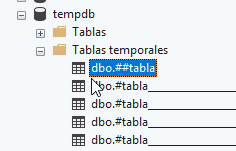

<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Variables de Tipo Tabla</font>**

</td>
</tr>
</table>



```
USE Northwind
GO
DECLARE @producto TABLE
(
	[ProductID] [int] IDENTITY(1,1)
	PRIMARY KEY	NOT NULL,
	[ProductName] [nvarchar](40) NOT NULL,
	[SupplierID] [int] NULL,
	[CategoryID] [int] NULL,
	[QuantityPerUnit] [nvarchar](20) NULL,
	[UnitPrice] [money] NULL,
	[UnitsInStock] [smallint] NULL,
	[UnitsOnOrder] [smallint] NULL,
	[ReorderLevel] [smallint] NULL,
	[Discontinued] [bit] NOT NULL
);

INSERT INTO @producto (ProductName, SupplierID, CategoryID, QuantityPerUnit, UnitPrice, UnitsInStock, UnitsOnOrder, ReorderLevel, Discontinued)
SELECT
	ProductName, SupplierID, CategoryID,
	QuantityPerUnit, UnitPrice, UnitsInStock,
	UnitsOnOrder, ReorderLevel, Discontinued
FROM dbo.Products
WHERE UnitPrice > 50 AND UnitsInStock < 20;

SELECT *
FROM @producto
GO
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Soporte de Vectores (Novedad 2025)</font>**

</td>
</tr>
</table>



```
USE Northwind;
GO
DROP TABLE IF EXISTS Documentos;
GO
CREATE TABLE Documentos (
    cod_doc_int INT PRIMARY KEY IDENTITY(1,1),
    nom_doc_nvc NVARCHAR(200),
    con_doc_nvc NVARCHAR(MAX),
    emb_doc_vec VECTOR(4)  -- Usando 4 dimensiones para el ejemplo
);
GO

INSERT INTO Documentos (nom_doc_nvc, con_doc_nvc, emb_doc_vec)
VALUES (
    'Documento 1',
    'Contenido del primer documento',
    CAST('[0.1, -0.3, 0.5, 0.2]' AS VECTOR(4))
);

INSERT INTO Documentos (nom_doc_nvc, con_doc_nvc, emb_doc_vec)
VALUES (
    'Documento 2',
    'Contenido del segundo documento',
    CAST('[0.2, -0.1, 0.4, 0.3]' AS VECTOR(4))
);

INSERT INTO Documentos (nom_doc_nvc, con_doc_nvc, emb_doc_vec)
VALUES (
    'Documento 3',
    'Contenido del tercer documento',
    CAST('[0.15, -0.25, 0.45, 0.25]' AS VECTOR(4))
);
GO

-- Consultar los datos
SELECT *
FROM Documentos;
GO
```



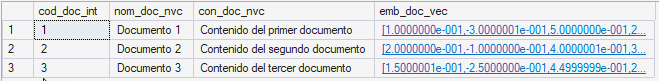